# Room Acoustics Simulation Report

This notebook models early reflections in a rectangular room using the image-source method, 
visualizes the resulting pressure fields, and focuses on identifying effective damper placement 
locations on room surfaces. The damper study ranks candidate placements by energy reduction at the 
listening position and exports results for review.


## Simulation workflow (step-by-step)
- Define the objective, expected outputs, and create a results folder structure for saved figures and animations.
- Configure room geometry, source/receiver positions, and acoustic parameters for the image-source model.
- Run the wave simulation and render a steady 3D pressure-field animation with a low-motion camera.
- Compute impulse-response metrics (RT60, clarity, decay) for baseline acoustic diagnostics.
- Sweep damper candidates across room surfaces and quantify energy reduction at the receiver.
- Rank damper placements, save per-configuration outputs, and present a final 3D animation of the best locations.


## Environment setup
This notebook uses NumPy for numeric grids and Plotly for interactive 3D rendering.


In [1]:
# !pip install numpy nbformat plotly
# !pip install tqdm

In [2]:
import numpy as np
from tqdm.auto import tqdm
from soundwaves import (
    SimulationConfig,
    RoomBox,
    SoundSource,
    WaveSimulation,
    WallDamper,
    compute_band_metrics,
    compute_metrics,
    damper_effects,
)
from soundwaves.visualization import (
    make_pro_animation,
    make_damper_effects_figure,
    make_impulse_response_comparison_figure,
    make_acoustic_report_figure,
    make_reflection_arrivals_figure,
)


/home/ubuntu/projects/simulations/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Core model imports
We model a room with the image-source method. The pressure field is the sum of delayed spherical waves:

$$
p(\mathbf{x}, t) = \sum_{i} (1-\alpha)^{N_i/2} \frac{A}{r_i} e^{-\beta r_i} \sum_k \sin(2\pi f_k (t - r_i/c) + \phi)
$$
where $\alpha$ is the wall (energy) absorption coefficient, so each reflection scales pressure by $\sqrt{1-\alpha}$, $\beta$ is air attenuation, and $r_i$ is distance to each image source.


## Configuration parameters
We define the room geometry, grid resolution, and acoustic parameters. Key definitions:

$$
c \approx 343\,\mathrm{m/s},
\quad t_n = n\,\Delta t,
\quad r_i = \|\mathbf{x} - \mathbf{x}_i\|
$$

- $\alpha$ (wall_absorption): average absorption coefficient, $0\le\alpha\le1$.
- $\beta$ (attenuation): air loss per meter in the propagation term $e^{-\beta r}$.
- reflection_order: maximum total number of wall reflections per image source.

The 3D field animation uses a low reflection order (cheap, readable wavefronts). The acoustic metrics use a separate high-order, 16 kHz impulse-response model so the reverberant tail and all octave bands up to 4 kHz are resolved.


In [3]:
config = SimulationConfig(
    nx=100,  # grid points along X (resolution)
    ny=50,  # grid points along Y (resolution)
    nz=27,  # grid points along Z (resolution)
    room_size=(10.0, 5.0, 2.7),  # room dimensions in meters (Lx, Ly, Lz)
    duration=0.1,  # simulation window in seconds
    dt=1 / 2000.0,  # time step in seconds
    reflection_order=2,  # image-source reflection depth (higher = more reflections)
    attenuation=0.01,  # air attenuation per meter (energy loss with distance)
    wall_absorption=0.2,  # average wall absorption coefficient (0 = rigid, 1 = fully absorbing)
)
room = RoomBox(size=config.room_size)
source_position = np.array([4.0, 2.0, 0.5])
receiver_position = np.array([6, 2.0, 1.8])
source = SoundSource.guitar_amp_spectrum(
    position=source_position,
    freq_min=80.0,
    freq_max=800.0,  # >= 4 grid cells per wavelength on the 0.1 m grid
    bands=8,
)
simulation = WaveSimulation(room=room, source=source, config=config)

# High-order model for impulse-response metrics (covers ~1 s of reverberant decay).
from dataclasses import replace
ir_config = replace(config, dt=1 / 16000.0, duration=1.0, reflection_order=150)
ir_simulation = WaveSimulation(room=room, source=source, config=ir_config)


In [4]:
from pathlib import Path
import csv

def _format_tag(value: float, digits: int = 2) -> str:
    return f"{value:.{digits}f}".replace('.', 'p')

results_root = Path('result')
results_root.mkdir(exist_ok=True)

config_tag = '_'.join([
    f"room{config.room_size[0]:.1f}x{config.room_size[1]:.1f}x{config.room_size[2]:.1f}",
    f"nx{config.nx}_ny{config.ny}_nz{config.nz}",
    f"abs{_format_tag(config.wall_absorption)}",
    f"ref{config.reflection_order}",
])
run_dir = results_root / config_tag
run_dir.mkdir(exist_ok=True)


## 3D field visualization (single view)
We visualize the pressure field $p(x,y,z,t)$ by rendering isosurfaces of constant magnitude: 
$|p| = \mathrm{const}$. A single view is used to keep the camera motion subtle and reduce cinematic orbiting.


In [5]:
import io
import plotly.graph_objects as go
import plotly.io as pio

def _frame_data_with_base(base_data, frame):
    data = list(base_data)
    if getattr(frame, 'traces', None):
        for trace_idx, trace in zip(frame.traces, frame.data):
            data[trace_idx] = trace
    else:
        for idx, trace in enumerate(frame.data):
            if idx < len(data):
                data[idx] = trace
            else:
                data.append(trace)
    return data


def save_animation_gif(fig, path, frame_duration_ms=40, scale=2):
    try:
        import imageio.v2 as imageio
    except Exception:
        import imageio
    images = []
    base_data = fig.data
    for frame in tqdm(fig.frames, desc="Rendering GIF frames"):
        frame_data = _frame_data_with_base(base_data, frame)
        frame_fig = go.Figure(data=frame_data, layout=fig.layout)
        png_bytes = pio.to_image(frame_fig, format='png', scale=scale)
        images.append(imageio.imread(io.BytesIO(png_bytes)))
    imageio.mimsave(path, images, duration=frame_duration_ms / 1000.0)


base_times = np.linspace(0.0, config.duration, 36, endpoint=False)
times = np.tile(base_times, 2)
figure = make_pro_animation(
    simulation,
    times,
    iso_level=0.04,
    render_stride=3,
    colorscale='RdBu',
    opacity=0.5,
    surface_count=2,
    background='white',
    axis_color='rgba(20,20,20,0.9)',
    grid_color='rgba(0,0,0,0.08)',
    show_grid=True,
    show_colorbar=True,
    frame_duration=30,
    transition_duration=0,
    easing='linear',
    camera_preset='front',
    camera_motion='sweep',
    camera_radius=1.35,
    camera_elevation=0.9,
    show_room=True,
    show_source=True,
    show_receiver=True,
    progress=True,
    receiver_position=receiver_position,
)
figure.data[0].name = 'Isosurface'
figure.data[1].name = 'Slice'
if len(figure.data) > 2:
    figure.data[2].name = 'Room'
if len(figure.data) > 3:
    figure.data[3].name = 'Source'
if len(figure.data) > 4:
    figure.data[4].name = 'Receiver'
figure.update_layout(
    title='Room Pressure Field (relative units)',
    showlegend=True,
    legend=dict(x=0.02, y=0.98),
    height=720,
    width=1200,
    margin=dict(l=10, r=10, t=60, b=10),
)
figure.show()

pressure_html_path = run_dir / 'pressure_field_animation.html'
figure.write_html(pressure_html_path, include_plotlyjs='cdn')

try:
    save_animation_gif(figure, run_dir / 'pressure_field_animation.gif', frame_duration_ms=30)
except Exception as exc:
    print(f'GIF export skipped: {exc}')


Isosurface frames:   0%|          | 0/72 [00:00<?, ?it/s]

Isosurface frames:   1%|▏         | 1/72 [00:00<00:23,  3.07it/s]

Isosurface frames:   3%|▎         | 2/72 [00:00<00:20,  3.40it/s]

Isosurface frames:   4%|▍         | 3/72 [00:00<00:19,  3.60it/s]

Isosurface frames:   6%|▌         | 4/72 [00:01<00:18,  3.75it/s]

...

Combine frames: 100%|██████████| 72/72 [00:00<00:00, 572.87it/s]

[Interactive 3D animation omitted from the saved notebook to keep it small; see result/*/pressure_slice_animation.gif or re-run the cell.]


Rendering GIF frames:   0%|          | 0/72 [00:00<?, ?it/s]

Rendering GIF frames:   0%|          | 0/72 [00:00<?, ?it/s]

GIF export skipped: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome




### Portable exports (matplotlib)
Plotly's static image export needs a headless Chrome, which is not available everywhere. The cell below renders a horizontal slice of the pressure field at listener height with matplotlib, so a shareable GIF is always produced.

In [6]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

xx, yy, zz = simulation.grid()
k = int(np.argmin(np.abs(zz[0, 0, :] - receiver_position[2])))
frames = [simulation.field_at(t)[:, :, k] for t in tqdm(base_times, desc="Slice frames")]
vmax = np.percentile(np.abs(frames), 99)

fig, ax = plt.subplots(figsize=(8, 4.2))
im = ax.imshow(frames[0].T, origin='lower', extent=[0, config.room_size[0], 0, config.room_size[1]],
               cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.plot(*source_position[:2], marker='*', color='gold', ms=14, mec='k', label='Source')
ax.plot(*receiver_position[:2], marker='o', color='deepskyblue', ms=9, mec='k', label='Receiver')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.legend(loc='upper right', fontsize=8)
fig.colorbar(im, ax=ax, label='Pressure (rel.)')
title = ax.set_title('')

def _update(i):
    im.set_data(frames[i].T)
    title.set_text(f'Pressure at z = {zz[0, 0, k]:.2f} m, t = {base_times[i] * 1e3:.1f} ms')
    return im, title

FuncAnimation(fig, _update, frames=len(frames)).save(run_dir / 'pressure_slice_animation.gif', writer=PillowWriter(fps=12))
plt.close(fig)

Slice frames:   0%|          | 0/36 [00:00<?, ?it/s]

Slice frames:   3%|▎         | 1/36 [00:00<00:09,  3.88it/s]

Slice frames:   6%|▌         | 2/36 [00:00<00:09,  3.43it/s]

Slice frames:   8%|▊         | 3/36 [00:00<00:09,  3.53it/s]

Slice frames:  11%|█         | 4/36 [00:01<00:08,  3.68it/s]

...

Slice frames:  92%|█████████▏| 33/36 [00:08<00:00,  3.83it/s]

Slice frames:  94%|█████████▍| 34/36 [00:09<00:00,  3.83it/s]

Slice frames:  97%|█████████▋| 35/36 [00:09<00:00,  3.84it/s]

Slice frames: 100%|██████████| 36/36 [00:09<00:00,  3.85it/s]

Slice frames: 100%|██████████| 36/36 [00:09<00:00,  3.68it/s]

## Acoustic analysis and treatment planning
We compute an impulse response $h(t)$ and derive metrics:

$$
EDC(t) = 10\log_{10} \frac{\int_t^\infty h^2(\tau) \, d\tau}{\int_0^\infty h^2(\tau) \, d\tau},
\quad RT60 = -60 / \text{slope}(EDC)
$$
Clarity uses early-to-late energy ratios: $C50$, $C80$, and $D50$.
Use the band plots below to decide where damping or bass trapping is most needed.


## Impulse response (time domain)
The first spike is direct sound. Early reflections within ~20 ms improve clarity,
while later strong reflections can smear transients.


In [7]:
from soundwaves.visualization import make_impulse_response_figure

rir = ir_simulation.impulse_response(receiver_position, progress=True)
rir_fig = make_impulse_response_figure(rir, show_decay=False, background="white", axis_color="rgba(20,20,20,0.9)", grid_color="rgba(0,0,0,0.08)")
rir_fig.update_layout(
    title="Impulse Response (relative units)",
    height=520,
    width=1200,
    margin=dict(l=60, r=40, t=60, b=50),
)
rir_fig.show()


## Energy decay curve (EDC)
The EDC shows how fast energy decays in dB. For small rooms, midband targets often fall around
0.2–0.4 s. Higher values suggest more absorption is needed.


In [8]:
from soundwaves.analysis import energy_decay_curve
import plotly.graph_objects as go

decay_db = energy_decay_curve(rir.response)
decay_fig = go.Figure()
decay_fig.add_trace(go.Scatter(x=rir.time, y=decay_db, mode="lines", line=dict(color="deepskyblue")))
decay_fig.update_layout(
    title="Energy Decay Curve (dB)",
    xaxis_title="Time (s)",
    yaxis_title="Decay (dB)",
    height=520,
    width=1200,
    margin=dict(l=60, r=40, t=60, b=50),
    plot_bgcolor="white",
    paper_bgcolor="white",
)
decay_fig.show()


## RT60 by octave band
Longer decay in low bands indicates the need for bass trapping. Aim for a smooth RT60 curve
across bands to avoid a boomy or dull response.


In [9]:
import plotly.graph_objects as go

band_metrics = compute_band_metrics(rir.response, ir_config.dt, progress=True)
centers = [int(c) for c in band_metrics.keys()]
rt60s = [band_metrics[c].rt60 if band_metrics[c].rt60 is not None else 0.0 for c in band_metrics] 
rt60_fig = go.Figure(data=[go.Bar(x=centers, y=rt60s, marker_color="mediumorchid")])
rt60_fig.update_layout(
    title="RT60 by Octave Band",
    xaxis_title="Center frequency (Hz)",
    yaxis_title="RT60 (s)",
    height=520,
    width=1200,
    margin=dict(l=60, r=40, t=60, b=50),
    plot_bgcolor="white",
    paper_bgcolor="white",
)
rt60_fig.show()


Octave bands:   0%|          | 0/6 [00:00<?, ?it/s]

Octave bands:  17%|█▋        | 1/6 [00:00<00:01,  3.10it/s]

Octave bands: 100%|██████████| 6/6 [00:00<00:00, 18.15it/s]

## Reverberation time vs. room-acoustics theory
Sabine and Eyring assume a *diffuse* field. A purely specular shoebox is not diffuse: rays travelling along the long axis hit walls rarely, so the late decay is slower than Eyring predicts. For an incoherent (high-frequency) image sum, the exact energy decay is the direction average

$$
\frac{dE}{dt} \propto \left\langle (1-\alpha)^{\,c t \sum_i |u_i| / L_i} \right\rangle_{\hat{u}},
$$

times the air-absorption factor $e^{-m c t}$. This is the right reference for this model. (`tests/test_physics.py` checks the 4 kHz band against it.)

| Estimate | RT60 (s) |
|:--|--:|
| Sabine (diffuse, no air) | 0.60 |
| Eyring (diffuse, with air) | 0.42 |
| Specular theory, T30 | 0.56 |
| Simulation 2 kHz band, T30 | 0.63 |
| Simulation 4 kHz band, T30 | 0.57 |

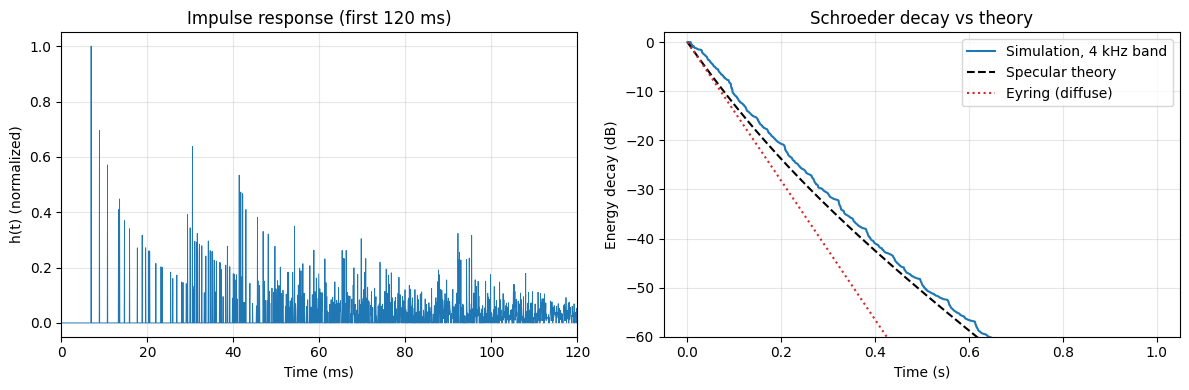

In [10]:
from soundwaves import eyring_rt60, sabine_rt60
from soundwaves.analysis import room_surface_area, _estimate_decay_slope, _octave_bandpass
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

lx, ly, lz = config.room_size
volume, surface, alpha = lx * ly * lz, room_surface_area(config.room_size), config.wall_absorption
air_m = 2 * config.attenuation  # pressure attenuation per metre -> energy attenuation

i = np.arange(4000) + 0.5
polar, azimuth = np.arccos(1 - 2 * i / i.size), np.pi * (1 + 5**0.5) * i
u = np.column_stack([np.cos(azimuth) * np.sin(polar), np.sin(azimuth) * np.sin(polar), np.cos(polar)])
rate = np.mean((1 - alpha) ** (config.c * rir.time[:, None] * (np.abs(u) @ (1 / np.array(config.room_size)))[None, :]), axis=1)
rate *= np.exp(-air_m * config.c * rir.time)
edc_theory = 10 * np.log10(np.cumsum(rate[::-1])[::-1] / rate.sum())

rows = [
    ('Sabine (diffuse, no air)', sabine_rt60(volume, surface * alpha)),
    ('Eyring (diffuse, with air)', eyring_rt60(volume, surface, alpha, air_m)),
    ('Specular theory, T30', -60 / _estimate_decay_slope(edc_theory, ir_config.dt, (-5, -35))),
    ('Simulation 2 kHz band, T30', band_metrics[2000.0].t30),
    ('Simulation 4 kHz band, T30', band_metrics[4000.0].t30),
]
display(Markdown('| Estimate | RT60 (s) |\n|:--|--:|\n' + '\n'.join(f'| {name} | {value:.2f} |' for name, value in rows)))

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))
ax0.plot(rir.time * 1e3, rir.response, lw=0.6, color='#1f77b4')
ax0.set_xlim(0, 120); ax0.set_xlabel('Time (ms)'); ax0.set_ylabel('h(t) (normalized)'); ax0.set_title('Impulse response (first 120 ms)')
ax1.plot(rir.time, energy_decay_curve(_octave_bandpass(rir.response, 1 / ir_config.dt, 2828, 5657)), label='Simulation, 4 kHz band')
ax1.plot(rir.time, edc_theory, '--', color='k', label='Specular theory')
eyring = eyring_rt60(volume, surface, alpha, air_m)
ax1.plot(rir.time, -60 * rir.time / eyring, ':', color='#d62728', label='Eyring (diffuse)')
ax1.set_ylim(-60, 2); ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Energy decay (dB)'); ax1.set_title('Schroeder decay vs theory'); ax1.legend()
for ax in (ax0, ax1): ax.grid(alpha=0.3)
plt.tight_layout(); fig.savefig(run_dir / 'impulse_response_and_decay.png', dpi=150); plt.show()

## Clarity by octave band (C50, C80)
Typical guidance: C50 > 3 dB for speech, C80 > 0 dB for music in small rooms.
Lower values imply too much late energy relative to early reflections.


In [11]:
c50s = [band_metrics[c].c50 if band_metrics[c].c50 is not None else 0.0 for c in band_metrics]
c80s = [band_metrics[c].c80 if band_metrics[c].c80 is not None else 0.0 for c in band_metrics]
clarity_fig = go.Figure()
clarity_fig.add_trace(go.Bar(x=centers, y=c50s, name="C50", marker_color="lightsalmon"))
clarity_fig.add_trace(go.Bar(x=centers, y=c80s, name="C80", marker_color="lightseagreen"))
clarity_fig.update_layout(
    title="Clarity by Octave Band",
    xaxis_title="Center frequency (Hz)",
    yaxis_title="Clarity (dB)",
    barmode="group",
    height=520,
    width=1200,
    margin=dict(l=60, r=40, t=60, b=50),
    plot_bgcolor="white",
    paper_bgcolor="white",
)
clarity_fig.show()


## Early reflection arrivals
Arrival times are $t_i = r_i / c$ with amplitudes scaled by absorption and distance.
Use this to identify dominant early reflections for panel placement.


In [12]:
arrivals_fig = make_reflection_arrivals_figure(
    simulation,
    receiver_position=receiver_position,
)
arrivals_fig.update_layout(
    title="Early Reflection Arrivals",
    height=520,
    width=1200,
    margin=dict(l=60, r=40, t=60, b=50),
)
arrivals_fig.show()


## Octave-band metrics table
Octave bands use $f_c/\sqrt{2}$ to $f_c\sqrt{2}$; the table provides precise numeric values
for treatment decisions.


In [13]:
from IPython.display import Markdown, display

band_metrics = compute_band_metrics(rir.response, ir_config.dt, progress=True)
rows = ["| Band (Hz) | RT60 (s) | C50 (dB) | C80 (dB) | D50 (%) |", "|---:|---:|---:|---:|---:|"]
for center_hz, metrics in tqdm(band_metrics.items(), desc="Metrics table"):
    rt60 = f"{metrics.rt60:.2f}" if metrics.rt60 is not None else "n/a"
    c50 = f"{metrics.c50:.1f}" if metrics.c50 is not None else "n/a"
    c80 = f"{metrics.c80:.1f}" if metrics.c80 is not None else "n/a"
    d50 = f"{metrics.d50:.1f}" if metrics.d50 is not None else "n/a"
    rows.append(f"| {int(center_hz)} | {rt60} | {c50} | {c80} | {d50} |")
display(Markdown("\n".join(rows)))


Octave bands:   0%|          | 0/6 [00:00<?, ?it/s]

Octave bands: 100%|██████████| 6/6 [00:00<00:00, 542.61it/s]

Metrics table:   0%|          | 0/6 [00:00<?, ?it/s]

Metrics table: 100%|██████████| 6/6 [00:00<00:00, 111353.20it/s]

| Band (Hz) | RT60 (s) | C50 (dB) | C80 (dB) | D50 (%) |
|---:|---:|---:|---:|---:|
| 125 | 0.74 | 2.5 | 6.9 | 63.9 |
| 250 | 0.71 | 0.3 | 4.1 | 51.9 |
| 500 | 0.52 | 2.3 | 4.7 | 63.1 |
| 1000 | 0.66 | 3.6 | 7.2 | 69.8 |
| 2000 | 0.63 | 5.6 | 8.8 | 78.5 |
| 4000 | 0.57 | 3.3 | 6.9 | 68.1 |

## Damper placement study (objective: find effective locations)
Absorbers at first-reflection points are meant to cut *early* reflections, so candidates are ranked by the reduction of early energy (first 50 ms after the direct sound, the D50 window) at the listener. A short, lower-order model is enough for that window and keeps the sweep fast.

In [14]:
def damper_grid_for_wall(wall: str, room_size, count_u=11, count_v=6, margin=0.4):
    lx, ly, lz = room_size
    wall = wall.lower()
    if wall in ('x0', 'xl'):
        x = 0.0 if wall == 'x0' else lx
        ys = np.linspace(margin, ly - margin, count_u)
        zs = np.linspace(margin, lz - margin, count_v)
        return [np.array([x, y, z]) for y in ys for z in zs]
    if wall in ('y0', 'yl'):
        y = 0.0 if wall == 'y0' else ly
        xs = np.linspace(margin, lx - margin, count_u)
        zs = np.linspace(margin, lz - margin, count_v)
        return [np.array([x, y, z]) for x in xs for z in zs]
    z = 0.0 if wall == 'z0' else lz
    xs = np.linspace(margin, lx - margin, count_u)
    ys = np.linspace(margin, ly - margin, count_v)
    return [np.array([x, y, z]) for x in xs for y in ys]

candidate_walls = ['x0', 'xl', 'y0', 'yl', 'z0', 'zl']
candidate_dampers = []
for wall in tqdm(candidate_walls, desc="Damper grid"):
    for center in damper_grid_for_wall(wall, config.room_size):
        candidate_dampers.append(
            WallDamper(wall=wall, center=center, radius=0.6, absorption=0.6)
        )

receiver_positions = {'listener': receiver_position}
direct_delay = np.linalg.norm(receiver_position - source_position) / config.c
early_config = replace(ir_config, duration=direct_delay + 0.05, reflection_order=20)
early_simulation = WaveSimulation(room=room, source=source, config=early_config)
effects = damper_effects(early_simulation, receiver_positions, candidate_dampers, progress=True)
effects_sorted = sorted(effects, key=lambda e: e.energy_reduction_pct, reverse=True)
top_effects = effects_sorted[:12]

summary_path = run_dir / 'damper_effects_summary.csv'
with summary_path.open('w', newline='') as handle:
    writer = csv.writer(handle)
    writer.writerow([
        'wall', 'center_x', 'center_y', 'center_z', 'radius', 'absorption',
        'energy_reduction_pct', 'energy_reduction_db'
    ])
    for effect in tqdm(effects_sorted, desc="Writing damper CSV"):
        center = effect.damper.center
        writer.writerow([
            effect.damper.wall,
            f'{center[0]:.3f}',
            f'{center[1]:.3f}',
            f'{center[2]:.3f}',
            f'{effect.damper.radius:.3f}',
            f'{effect.damper.absorption:.3f}',
            f'{effect.energy_reduction_pct:.3f}',
            f'{effect.energy_reduction_db:.3f}',
        ])

rows = [
    '| Rank | Wall | Center (x, y, z) m | Energy reduction (%) |',
    '|---:|:---:|:---|---:|',
]
for idx, effect in enumerate(tqdm(top_effects, desc="Top dampers"), start=1):
    center = effect.damper.center
    rows.append(
        f'| {idx} | {effect.damper.wall} | ({center[0]:.2f}, {center[1]:.2f}, {center[2]:.2f}) | {effect.energy_reduction_pct:.2f} |'
    )
from IPython.display import Markdown, display
display(Markdown('\n'.join(rows)))

effects_fig = make_damper_effects_figure(top_effects, background='white', axis_color='rgba(20,20,20,0.9)', grid_color='rgba(0,0,0,0.08)')
effects_fig.update_layout(height=520, width=1200, margin=dict(l=60, r=40, t=60, b=60))
effects_fig.show()
try:
    effects_fig.write_image(run_dir / 'damper_effects_top.png')
except Exception as exc:
    print(f'PNG export skipped: {exc}')

def _damper_folder_name(effect):
    center = effect.damper.center
    return '_'.join([
        f"wall{effect.damper.wall}",
        f"x{_format_tag(center[0])}",
        f"y{_format_tag(center[1])}",
        f"z{_format_tag(center[2])}",
        f"r{_format_tag(effect.damper.radius)}",
        f"abs{_format_tag(effect.damper.absorption)}",
    ])

for effect in tqdm(top_effects, desc="Damper comparisons"):
    sim_dir = run_dir / _damper_folder_name(effect)
    comparison_fig = make_impulse_response_comparison_figure(
        early_simulation, receiver_position, effect.damper,
        background='white', axis_color='rgba(20,20,20,0.9)', grid_color='rgba(0,0,0,0.08)'
    )
    comparison_fig.update_layout(height=520, width=1200, margin=dict(l=60, r=40, t=60, b=60))
    try:
        sim_dir.mkdir(exist_ok=True)
        comparison_fig.write_image(sim_dir / 'impulse_response_comparison.png')
    except Exception as exc:
        print(f'PNG export skipped: {exc}')
        try:
            if sim_dir.exists() and not any(sim_dir.iterdir()):
                sim_dir.rmdir()
        except Exception:
            pass


Damper grid:   0%|          | 0/6 [00:00<?, ?it/s]

Damper grid: 100%|██████████| 6/6 [00:00<00:00, 7976.49it/s]

Damper sweep:   0%|          | 0/397 [00:00<?, ?it/s]

Damper sweep:  12%|█▏        | 48/397 [00:00<00:00, 475.00it/s]

Damper sweep:  24%|██▍       | 96/397 [00:00<00:00, 457.59it/s]

...

PNG export skipped: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome




Damper comparisons:   0%|          | 0/12 [00:00<?, ?it/s]

Damper comparisons:  83%|████████▎ | 10/12 [00:00<00:00, 95.84it/s]

Damper comparisons: 100%|██████████| 12/12 [00:00<00:00, 78.30it/s]

PNG export skipped: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome


PNG export skipped: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome


PNG export skipped: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome


PNG export skipped: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome


PNG export skipp

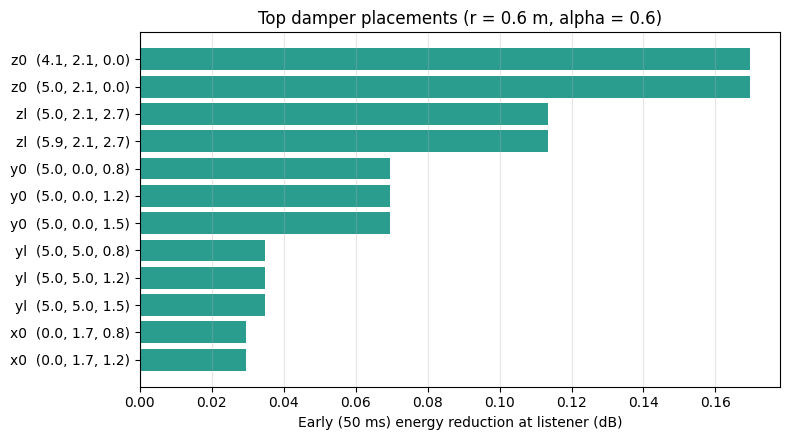

In [15]:
import matplotlib.pyplot as plt

labels = [f"{e.damper.wall}  ({e.damper.center[0]:.1f}, {e.damper.center[1]:.1f}, {e.damper.center[2]:.1f})" for e in top_effects]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(labels[::-1], [e.energy_reduction_db for e in top_effects][::-1], color='#2a9d8f')
ax.set_xlabel('Early (50 ms) energy reduction at listener (dB)')
ax.set_title(f'Top damper placements (r = {top_effects[0].damper.radius} m, alpha = {top_effects[0].damper.absorption})')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); fig.savefig(run_dir / 'damper_ranking.png', dpi=150); plt.show()

## Damper placement results animation
A separate 3D animation highlights the top-ranked damper locations and is exported to the results folder.


In [16]:
import plotly.graph_objects as go

all_centers = np.array([effect.damper.center for effect in effects_sorted])
all_scores = np.array([effect.energy_reduction_pct for effect in effects_sorted])
top_effects = effects_sorted[:12]

base_trace = go.Scatter3d(
    x=all_centers[:, 0],
    y=all_centers[:, 1],
    z=all_centers[:, 2],
    mode='markers',
    marker=dict(size=4, color=all_scores, colorscale='Viridis', colorbar=dict(title='Reduction %')),
    name='Candidates',
)
source_trace = go.Scatter3d(
    x=[source_position[0]],
    y=[source_position[1]],
    z=[source_position[2]],
    mode='markers',
    marker=dict(size=6, color='gold'),
    name='Source',
)
receiver_trace = go.Scatter3d(
    x=[receiver_position[0]],
    y=[receiver_position[1]],
    z=[receiver_position[2]],
    mode='markers',
    marker=dict(size=6, color='deepskyblue'),
    name='Receiver',
)
highlight_trace = go.Scatter3d(
    x=[top_effects[0].damper.center[0]],
    y=[top_effects[0].damper.center[1]],
    z=[top_effects[0].damper.center[2]],
    mode='markers+text',
    marker=dict(size=10, color='crimson'),
    text=[f"{top_effects[0].damper.wall} {top_effects[0].energy_reduction_pct:.1f}%"],
    textposition='top center',
    name='Top damper',
)

frames = []
for effect in tqdm(top_effects, desc="Building frames"):
    center = effect.damper.center
    label = f"{effect.damper.wall} {effect.energy_reduction_pct:.1f}%"
    frames.append(
        go.Frame(
            data=[
                go.Scatter3d(
                    x=[center[0]],
                    y=[center[1]],
                    z=[center[2]],
                    mode='markers+text',
                    marker=dict(size=10, color='crimson'),
                    text=[label],
                    textposition='top center',
                )
            ],
            traces=[3],
            name=label,
        )
    )

fig = go.Figure(
    data=[base_trace, source_trace, receiver_trace, highlight_trace],
    frames=frames,
)

lx, ly, lz = config.room_size
fig.update_layout(
    scene=dict(
        xaxis=dict(title='X (m)', range=[0, lx]),
        yaxis=dict(title='Y (m)', range=[0, ly]),
        zaxis=dict(title='Z (m)', range=[0, lz]),
        aspectmode='data',
        bgcolor='white',
        camera=dict(eye=dict(x=1.4, y=1.4, z=0.8)),
    ),
    title='Top damper locations (3D sweep)',
    height=720,
    width=1200,
    margin=dict(l=10, r=10, t=60, b=10),
    updatemenus=[
        dict(
            type='buttons',
            showactive=False,
            buttons=[
                dict(
                    label='Play',
                    method='animate',
                    args=[None, {'frame': {'duration': 650, 'redraw': True}, 'fromcurrent': True}],
                ),
                dict(
                    label='Pause',
                    method='animate',
                    args=[[None], {'frame': {'duration': 0}, 'mode': 'immediate'}],
                ),
            ],
        )
    ],
    sliders=[
        dict(
            steps=[
                dict(
                    method='animate',
                    args=[[frame.name], {'mode': 'immediate', 'frame': {'duration': 0, 'redraw': True}}],
                    label=frame.name,
                )
                for frame in frames
            ],
            currentvalue=dict(prefix='Top damper: '),
        )
    ],
)
fig.show()

damper_anim_path = run_dir / 'damper_placement_animation.html'
fig.write_html(damper_anim_path, include_plotlyjs='cdn')


Building frames:   0%|          | 0/12 [00:00<?, ?it/s]

Building frames: 100%|██████████| 12/12 [00:00<00:00, 3330.13it/s]

## Damper placement table (recommended wall positions)
The table below lists the top damper candidates per wall, ranked by energy reduction at the receiver.


In [17]:
from IPython.display import Markdown, display
from collections import defaultdict

per_wall = defaultdict(list)
for effect in tqdm(effects_sorted, desc="Grouping by wall"):
    per_wall[effect.damper.wall].append(effect)

rows = [
    '| Wall | Rank | Center (x, y, z) m | Energy reduction (%) |',
    '|:---:|---:|:---|---:|',
]
for wall in tqdm(sorted(per_wall.keys()), desc="Ranking per wall"):
    ranked = sorted(per_wall[wall], key=lambda e: e.energy_reduction_pct, reverse=True)[:5]
    for rank, effect in enumerate(ranked, start=1):
        center = effect.damper.center
        rows.append(
            f'| {wall} | {rank} | ({center[0]:.2f}, {center[1]:.2f}, {center[2]:.2f}) | {effect.energy_reduction_pct:.2f} |'
        )

display(Markdown('\n'.join(rows)))


Grouping by wall:   0%|          | 0/396 [00:00<?, ?it/s]

Grouping by wall: 100%|██████████| 396/396 [00:00<00:00, 1085584.56it/s]

Ranking per wall:   0%|          | 0/6 [00:00<?, ?it/s]

Ranking per wall: 100%|██████████| 6/6 [00:00<00:00, 38716.65it/s]

| Wall | Rank | Center (x, y, z) m | Energy reduction (%) |
|:---:|---:|:---|---:|
| x0 | 1 | (0.00, 1.66, 0.78) | 0.68 |
| x0 | 2 | (0.00, 1.66, 1.16) | 0.68 |
| x0 | 3 | (0.00, 2.08, 0.78) | 0.68 |
| x0 | 4 | (0.00, 2.08, 1.16) | 0.68 |
| x0 | 5 | (0.00, 2.08, 1.54) | 0.68 |
| xl | 1 | (10.00, 1.66, 1.16) | 0.68 |
| xl | 2 | (10.00, 1.66, 1.54) | 0.68 |
| xl | 3 | (10.00, 2.08, 0.78) | 0.68 |
| xl | 4 | (10.00, 2.08, 1.16) | 0.68 |
| xl | 5 | (10.00, 2.08, 1.54) | 0.68 |
| y0 | 1 | (5.00, 0.00, 0.78) | 1.59 |
| y0 | 2 | (5.00, 0.00, 1.16) | 1.59 |
| y0 | 3 | (5.00, 0.00, 1.54) | 1.59 |
| y0 | 4 | (0.40, 0.00, 0.40) | 0.00 |
| y0 | 5 | (0.40, 0.00, 0.78) | 0.00 |
| yl | 1 | (5.00, 5.00, 0.78) | 0.80 |
| yl | 2 | (5.00, 5.00, 1.16) | 0.80 |
| yl | 3 | (5.00, 5.00, 1.54) | 0.80 |
| yl | 4 | (0.40, 5.00, 0.40) | 0.00 |
| yl | 5 | (0.40, 5.00, 0.78) | 0.00 |
| z0 | 1 | (4.08, 2.08, 0.00) | 3.83 |
| z0 | 2 | (5.00, 2.08, 0.00) | 3.83 |
| z0 | 3 | (0.40, 0.40, 0.00) | 0.00 |
| z0 | 4 | (0.40, 1.24, 0.00) | 0.00 |
| z0 | 5 | (0.40, 2.08, 0.00) | 0.00 |
| zl | 1 | (5.00, 2.08, 2.70) | 2.58 |
| zl | 2 | (5.92, 2.08, 2.70) | 2.58 |
| zl | 3 | (0.40, 0.40, 2.70) | 0.00 |
| zl | 4 | (0.40, 1.24, 2.70) | 0.00 |
| zl | 5 | (0.40, 2.08, 2.70) | 0.00 |